# Basic Investment Model — Bayesian Phase 1 Validation

Validates the Bayesian estimation pipeline on the frictionless basic-investment
model, where the analytical policy is exact (`cost_convex == 0`,
`cost_fixed == 0`). Any inference error is therefore attributable to the
inference machinery itself, not to solver approximation.

Pipeline (matches `docs/paper/Bayesian.md` §2):

- **Filter**: Kalman (exact, via `tfp.distributions.LinearGaussianStateSpaceModel`).
- **Sampler**: NUTS (gradient-based, via `tfp.mcmc.NoUTurnSampler` with dual-averaging step-size adaptation).
- **DGP**: `BasicInvestmentEnv.simulate_smm_panel_data(mode="frictionless_analytical")` plus an
  iid Gaussian measurement-noise overlay on log-revenue (`η ~ N(0, σ_η²)`).
- **Validation**: single-run posterior recovery (§3) + an `R`-replicate coverage check (§4-5; Bayesian.md §2.8).

Three profiles below — `SMOKE` for quick sanity, `FULL` for a heavy single-run
demonstration paired with a small coverage check, `COVERAGE_CHECK` for the
full §2.8 procedure.  Compute is deterministic on CPU by default
(`USE_GPU = False`); flip to True for Colab GPU/TPU acceleration at the cost
of bit-identical reruns.

# Section 0: Setup

In [1]:
from pathlib import Path
import os
import sys
import time
import warnings
from dataclasses import asdict

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
warnings.filterwarnings('ignore', message=r'.*does not produce the same series as CPU implementation.*')
warnings.filterwarnings('ignore', message=r'.*casting an input of type complex64.*')

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# ----- Compute backend toggle ---------------------------------------------
# Default: CPU only.  TF stateless RNG is bit-identical across machines on
# CPU but not on Metal/GPU/TPU, which would violate the reproducibility
# claim in Bayesian.md §2.9.  Flip USE_GPU = True for Colab acceleration
# when you don't need bit-identical reruns.
USE_GPU = False

import tensorflow as tf
if not USE_GPU:
    tf.config.set_visible_devices([], 'GPU')
# Silence the LGSSM internal stationary-variance complex64→float32 warning
# (benign: real-only computation routed through a complex code path).
tf.get_logger().setLevel('ERROR')

import tensorflow_probability as tfp

print(f'tf: {tf.__version__}   tfp: {tfp.__version__}')
print(f'logical devices: {[d.device_type for d in tf.config.list_logical_devices()]}')

from src.v2.estimation import (
    BayesianCoverageConfig,
    BayesianRunConfig,
    run_coverage_check,
    run_mcmc,
)
from src.v2.estimation.bayesian_basic_investment import (
    bayesian_true_beta,
    make_bayesian_spec,
)
from src.v2.environments.basic_investment import (
    BasicInvestmentEnv,
    EconomicParams,
    ShockParams,
)
from src.v2.evaluation import prepare_evaluation_run, save_manifest_sections
from src.v2.utils.seeding import fold_in_seed

np.set_printoptions(precision=6, suppress=True)

/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


tf: 2.16.2   tfp: 0.24.0
logical devices: ['CPU']


# Section 1: Config

Three profiles.  `SMOKE` for fast end-to-end check (~3 min); `FULL` for a
heavy single-run sanity demonstration paired with a small coverage check
(~15 min); `COVERAGE_CHECK` for the full §2.8 procedure (~30+ min).

Each profile separates the **sanity** MCMC (§3) from the **coverage**
MCMC (§4-5): the former carries the bulk of the compute budget; the latter
runs at a lighter spec since R replicates aggregate together for the
coverage statistic.

In [2]:
PROFILE = 'FULL'   # 'SMOKE' | 'FULL' | 'COVERAGE_CHECK'

PROFILES = {
    'SMOKE': {
        'description': ('Quick smoke test: 2 chains × (200 warmup + 200 samples), '
                        'N=30 T=20 sanity; R=2 coverage at same spec. ~3 min total.'),
        'mcmc_sanity':   dict(n_chains=2, n_warmup=200, n_samples=200,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'mcmc_coverage': dict(n_chains=2, n_warmup=200, n_samples=200,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'sanity':   dict(n_firms=30, horizon=20, burn_in=20),
        'coverage': dict(n_replicates=2, n_firms=30, horizon=20, burn_in=20,
                         credible_level=0.95),
    },
    'FULL': {
        'description': ('Heavy single-run sanity (2 chains × (600 warmup + 800 samples), '
                        'N=80 T=30; ~12 min) + lightweight coverage '
                        '(R=4 × tiny MCMC; ~3 min).  Total ~15-16 min.'),
        'mcmc_sanity':   dict(n_chains=2, n_warmup=600, n_samples=800,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'mcmc_coverage': dict(n_chains=2, n_warmup=150, n_samples=200,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'sanity':   dict(n_firms=80, horizon=30, burn_in=30),
        'coverage': dict(n_replicates=4, n_firms=30, horizon=18, burn_in=15,
                         credible_level=0.95),
    },
    'COVERAGE_CHECK': {
        'description': ('Full coverage check: 2 chains × (500 warmup + 500 samples), '
                        'N=60 T=30 both sanity & coverage; R=10. ~30+ min.'),
        'mcmc_sanity':   dict(n_chains=2, n_warmup=500, n_samples=500,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'mcmc_coverage': dict(n_chains=2, n_warmup=500, n_samples=500,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'sanity':   dict(n_firms=60, horizon=30, burn_in=30),
        'coverage': dict(n_replicates=10, n_firms=60, horizon=30, burn_in=30,
                         credible_level=0.95),
    },
}

assert PROFILE in PROFILES, f'Unknown profile: {PROFILE!r}'
PROFILE_CONFIG = PROFILES[PROFILE]

# Ground truth — env's structural parameters, plus an exogenous σ_η.
TRUE_ALPHA = 0.6
TRUE_RHO = 0.7
TRUE_SIG_EPS = 0.15
TRUE_SIG_ETA = 0.05

# Fixed (calibrated) — not estimated.
INTEREST_RATE = 0.04
DEPRECIATION_RATE = 0.15

MCMC_SANITY    = BayesianRunConfig(**PROFILE_CONFIG['mcmc_sanity'])
MCMC_COVERAGE  = BayesianRunConfig(**PROFILE_CONFIG['mcmc_coverage'])
SANITY_PANEL   = PROFILE_CONFIG['sanity']
COV_CONFIG     = BayesianCoverageConfig(**PROFILE_CONFIG['coverage'])

# ----- Output directory for paper-grade tables and figures ---------------
FIGURES_ROOT = REPO_ROOT / 'docs' / 'paper' / 'figures' / 'bayesian-frictionless'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

SAVE_RUN = True
RUN_TAG  = f'bayesian-phase1-{PROFILE.lower()}'
EXPERIMENT_NAME = 'basic_investment_bayesian_validation'
RESULTS_ROOT    = str(REPO_ROOT / 'outputs' / 'notebooks')

RUN = prepare_evaluation_run(
    EXPERIMENT_NAME, save_run=SAVE_RUN, run_tag=RUN_TAG,
    results_root=RESULTS_ROOT,
)

print(f'Profile: {PROFILE} — {PROFILE_CONFIG["description"]}')
print(f'Run output : {RUN["run_dir"]}')
print(f'Figures dir: {FIGURES_ROOT}')
print()
print(f'Sanity MCMC:   n_chains={MCMC_SANITY.n_chains}, n_warmup={MCMC_SANITY.n_warmup}, '
      f'n_samples={MCMC_SANITY.n_samples}; panel N={SANITY_PANEL["n_firms"]}, T={SANITY_PANEL["horizon"]}')
print(f'Coverage MCMC: n_chains={MCMC_COVERAGE.n_chains}, n_warmup={MCMC_COVERAGE.n_warmup}, '
      f'n_samples={MCMC_COVERAGE.n_samples}; R={COV_CONFIG.n_replicates}, '
      f'panel N={COV_CONFIG.n_firms}, T={COV_CONFIG.horizon}')

Profile: FULL — Heavy single-run sanity (2 chains × (600 warmup + 800 samples), N=80 T=30; ~12 min) + lightweight coverage (R=4 × tiny MCMC; ~3 min).  Total ~15-16 min.
Run output : /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/basic_investment_bayesian_validation/bayesian-phase1-full
Figures dir: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/docs/paper/figures/bayesian-frictionless

Sanity MCMC:   n_chains=2, n_warmup=600, n_samples=800; panel N=80, T=30
Coverage MCMC: n_chains=2, n_warmup=150, n_samples=200; R=4, panel N=30, T=18


# Section 2: Environment + Bayesian Spec

Build the frictionless env at the ground-truth structural parameters, then
build the `BayesianSpec`.  The spec carries: parameter names, prior
distribution, bijector, likelihood (Kalman closure), and a synthetic-panel
factory closed over the env.

Table saved to `paper/figures/bayesian-frictionless/prior_table.csv`.

In [3]:
econ = EconomicParams(
    interest_rate=INTEREST_RATE,
    depreciation_rate=DEPRECIATION_RATE,
    production_elasticity=TRUE_ALPHA,
    cost_convex=0.0,
    cost_fixed=0.0,
)
shocks = ShockParams(mu=0.0, rho=TRUE_RHO, sigma=TRUE_SIG_EPS)
env = BasicInvestmentEnv(econ_params=econ, shock_params=shocks)

spec = make_bayesian_spec(env)
beta_true = bayesian_true_beta(env, sigma_eta=TRUE_SIG_ETA)

prior_table = pd.DataFrame([
    {'parameter': 'alpha',         'true': beta_true['alpha'],         'prior': 'Beta(2, 2)',      'support': '(0, 1)',  'bijector': 'Sigmoid'},
    {'parameter': 'rho',           'true': beta_true['rho'],           'prior': 'Beta(2, 2)',      'support': '(0, 1)',  'bijector': 'Sigmoid'},
    {'parameter': 'sigma_epsilon', 'true': beta_true['sigma_epsilon'], 'prior': 'HalfNormal(0.3)', 'support': '(0, inf)', 'bijector': 'Exp'},
    {'parameter': 'sigma_eta',     'true': beta_true['sigma_eta'],     'prior': 'HalfNormal(0.1)', 'support': '(0, inf)', 'bijector': 'Exp'},
])
print(f'filter_kind: {spec.filter_kind.value}   sampler_kind: {spec.sampler_kind.value}')
print(f'observation_keys: {spec.observation_keys}')
display(prior_table)
prior_table.to_csv(FIGURES_ROOT / 'prior_table.csv', index=False)

save_manifest_sections(
    RUN,
    setup={'profile': PROFILE, 'description': PROFILE_CONFIG['description'],
           'use_gpu': USE_GPU},
    environment={'economic_params': asdict(econ), 'shock_params': asdict(shocks)},
    true_beta=beta_true,
    mcmc_sanity_config=asdict(MCMC_SANITY),
    mcmc_coverage_config=asdict(MCMC_COVERAGE),
    sanity_panel=SANITY_PANEL,
    coverage_config=asdict(COV_CONFIG),
)

filter_kind: kalman   sampler_kind: nuts
observation_keys: ('y', 'log_k')


,parameter,true,prior,support,bijector
0,alpha,0.60,"Beta(2, 2)","(0, 1)",Sigmoid
1,rho,0.70,"Beta(2, 2)","(0, 1)",Sigmoid
2,sigma_epsilon,0.15,HalfNormal(0.3),"(0, inf)",Exp
3,sigma_eta,0.05,HalfNormal(0.1),"(0, inf)",Exp


PosixPath('/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/basic_investment_bayesian_validation/bayesian-phase1-full/manifest.json')

# Section 3: Single-Run Sanity Check

Synthesize one panel at `beta_true`, run NUTS on it, and inspect the posterior.
This section carries the bulk of the FULL profile's compute budget; numbers
here directly determine posterior precision.

- **Table 1**: posterior summary (median, 95% CI, R-hat, ESS) vs. truth.
- **Plot 1**: trace plots — visual chain mixing check.
- **Plot 2**: posterior marginal densities with true-value markers.

All saved under `paper/figures/bayesian-frictionless/`.

Seed plumbing follows §2.9: a single master pair derives all sub-seeds via
`fold_in_seed`.  Token-scoped folding means panel and MCMC draws are
independent.

In [4]:
SANITY_MASTER = MCMC_SANITY.master_seed
panel_seed = fold_in_seed(SANITY_MASTER, 'sanity', 'panel')
mcmc_seed  = fold_in_seed(SANITY_MASTER, 'sanity', 'mcmc')

panel = spec.synthesize_panel_fn(
    beta_true,
    n_firms=SANITY_PANEL['n_firms'],
    horizon=SANITY_PANEL['horizon'],
    burn_in=SANITY_PANEL['burn_in'],
    seed=panel_seed,
)
observed = {k: panel[k] for k in spec.observation_keys}
print(f'panel shapes: y={panel["y"].shape}, log_k={panel["log_k"].shape}')

t0 = time.perf_counter()
mcmc_result = run_mcmc(spec, observed, MCMC_SANITY, seed=mcmc_seed)
sanity_wall = time.perf_counter() - t0
print(f'MCMC wall time: {sanity_wall:.1f} s   acceptance: {mcmc_result.acceptance_rate:.3f}')

# Table 1
rows = []
for k in spec.parameter_names:
    s = mcmc_result.posterior_samples[k]
    rows.append({
        'parameter': k,
        'true':       beta_true[k],
        'median':     float(np.median(s)),
        'ci_low_2.5': float(np.quantile(s, 0.025)),
        'ci_hi_97.5': float(np.quantile(s, 0.975)),
        'r_hat':      mcmc_result.r_hat[k],
        'ess':        mcmc_result.ess[k],
    })
posterior_table = pd.DataFrame(rows)
print('Table 1. Posterior summary at beta_true (single-panel sanity check)')
display(posterior_table)
posterior_table.to_csv(FIGURES_ROOT / 'table1_posterior_summary.csv', index=False)

panel shapes: y=(80, 30, 1), log_k=(80, 30, 1)
MCMC wall time: 696.3 s   acceptance: 0.845
Table 1. Posterior summary at beta_true (single-panel sanity check)


,parameter,true,median,ci_low_2.5,ci_hi_97.5,r_hat,ess
0,alpha,0.60,0.602798,0.595920,0.609846,0.998750,1600.000000
1,rho,0.70,0.679145,0.647693,0.715381,1.001269,513.331238
2,sigma_epsilon,0.15,0.158898,0.149754,0.164489,1.038086,326.796936
3,sigma_eta,0.05,0.020176,0.001942,0.047636,1.041078,146.010635


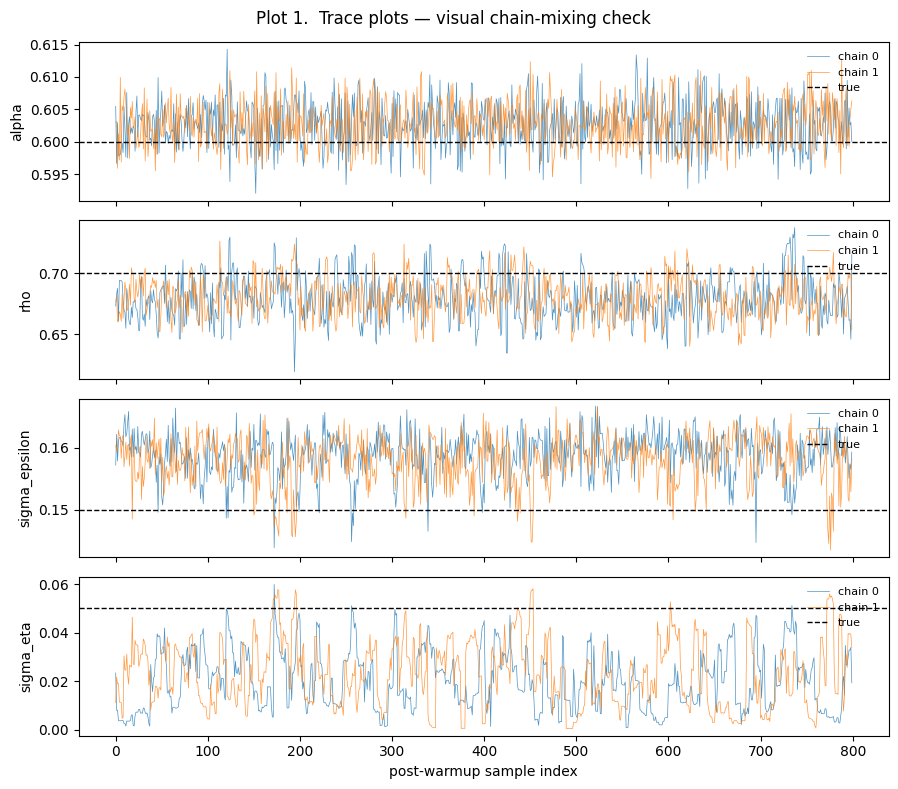

In [5]:
# Plot 1: trace plots
fig, axes = plt.subplots(len(spec.parameter_names), 1,
                         figsize=(9, 2.0 * len(spec.parameter_names)),
                         sharex=True)
for ax, k in zip(axes, spec.parameter_names):
    s = mcmc_result.posterior_samples[k]   # (n_samples, n_chains)
    for c in range(s.shape[1]):
        ax.plot(s[:, c], lw=0.5, alpha=0.8, label=f'chain {c}')
    ax.axhline(beta_true[k], color='k', lw=1.0, ls='--', label='true')
    ax.set_ylabel(k); ax.legend(loc='upper right', fontsize=8, frameon=False)
axes[-1].set_xlabel('post-warmup sample index')
plt.suptitle('Plot 1.  Trace plots — visual chain-mixing check')
plt.tight_layout()
plt.savefig(FIGURES_ROOT / 'plot1_trace.png', dpi=140, bbox_inches='tight')
plt.show()

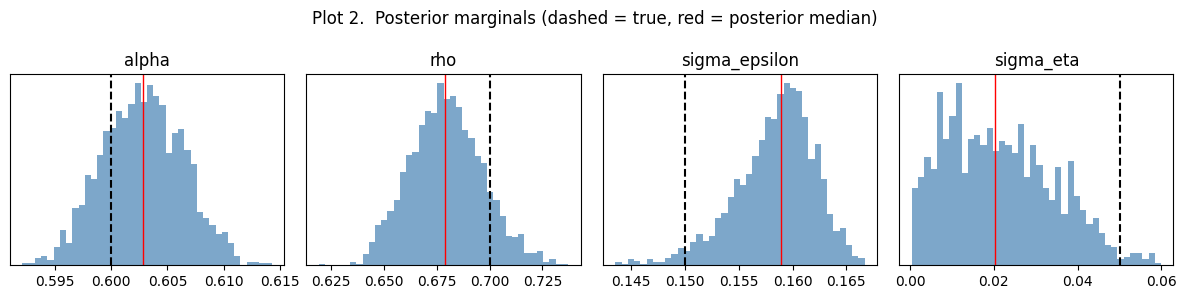

In [6]:
# Plot 2: posterior marginals
fig, axes = plt.subplots(1, len(spec.parameter_names),
                         figsize=(3.0 * len(spec.parameter_names), 3))
for ax, k in zip(axes, spec.parameter_names):
    s = mcmc_result.posterior_samples[k].reshape(-1)
    ax.hist(s, bins=40, alpha=0.7, density=True, color='steelblue')
    ax.axvline(beta_true[k], color='k', lw=1.5, ls='--')
    ax.axvline(np.median(s), color='red', lw=1.0)
    ax.set_title(k); ax.set_yticks([])
plt.suptitle('Plot 2.  Posterior marginals (dashed = true, red = posterior median)')
plt.tight_layout()
plt.savefig(FIGURES_ROOT / 'plot2_marginals.png', dpi=140, bbox_inches='tight')
plt.show()

# Section 4: Coverage Check (Bayesian.md §2.8)

For `R` replicates:

1. Draw β₀ from the prior.
2. Synthesize one panel at β₀ via the analytical-policy DGP + measurement noise.
3. Run MCMC at `MCMC_COVERAGE` spec (lighter than sanity — replicates aggregate).
4. Report the 95% credible interval per parameter.

**Pass**: empirical coverage close to 95% per parameter.
All seed routing matches §2.9.  Table saved to `paper/figures/bayesian-frictionless/`.

In [7]:
t0 = time.perf_counter()
coverage_result = run_coverage_check(
    spec, MCMC_COVERAGE, COV_CONFIG,
    master_seed=MCMC_COVERAGE.master_seed,
)
coverage_wall = time.perf_counter() - t0
print(f'Coverage wall time: {coverage_wall:.1f} s '
      f'({COV_CONFIG.n_replicates} replicates, ~{coverage_wall/COV_CONFIG.n_replicates:.0f}s each)')

# Table 2: coverage
rows = []
for k in spec.parameter_names:
    rows.append({
        'parameter': k,
        'target':    coverage_result.credible_level,
        'empirical': coverage_result.coverage_per_parameter[k],
        'pass':      coverage_result.coverage_per_parameter[k] >= 0.80,   # loose at small R
    })
coverage_table = pd.DataFrame(rows)
print('Table 2. Coverage by parameter (95% credible interval)')
display(coverage_table)
coverage_table.to_csv(FIGURES_ROOT / 'table2_coverage.csv', index=False)

Coverage wall time: 332.0 s (4 replicates, ~83s each)
Table 2. Coverage by parameter (95% credible interval)


,parameter,target,empirical,pass
0,alpha,0.95,1.00,True
1,rho,0.95,1.00,True
2,sigma_epsilon,0.95,1.00,True
3,sigma_eta,0.95,0.75,False


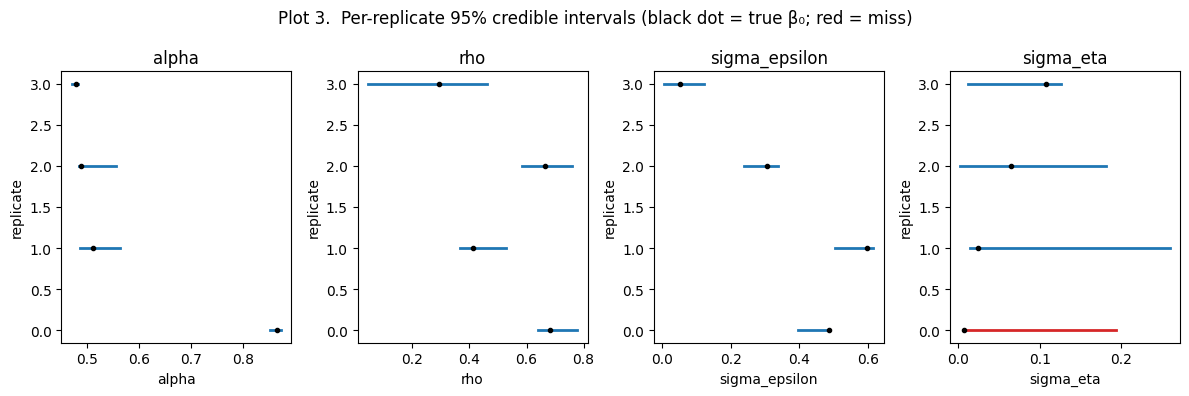

In [8]:
# Plot 3: per-replicate intervals with true-value markers
fig, axes = plt.subplots(1, len(spec.parameter_names),
                         figsize=(3.0 * len(spec.parameter_names), 4),
                         sharey=False)
for ax, k in zip(axes, spec.parameter_names):
    R = COV_CONFIG.n_replicates
    for r in range(R):
        lo, hi = coverage_result.per_replicate_intervals[r][k]
        b0 = coverage_result.per_replicate_beta0[r][k]
        contains = lo <= b0 <= hi
        col = 'tab:blue' if contains else 'tab:red'
        ax.plot([lo, hi], [r, r], lw=2, color=col)
        ax.plot([b0], [r], 'o', color='k', markersize=3)
    ax.set_title(k); ax.set_xlabel(k); ax.set_ylabel('replicate')
plt.suptitle('Plot 3.  Per-replicate 95% credible intervals (black dot = true β₀; '
             'red = miss)')
plt.tight_layout()
plt.savefig(FIGURES_ROOT / 'plot3_coverage_intervals.png', dpi=140, bbox_inches='tight')
plt.show()

# Section 5: Diagnostics Summary

In [9]:
diag_rows = []
for r, d in enumerate(coverage_result.per_replicate_diagnostics):
    row = {'replicate': r, 'acceptance': d['acceptance_rate'],
           'wall_time_sec': d['wall_time_sec']}
    for k in spec.parameter_names:
        row[f'r_hat_{k}'] = d['r_hat'][k]
        row[f'ess_{k}']   = d['ess'][k]
    diag_rows.append(row)
diag_table = pd.DataFrame(diag_rows)
print('Per-replicate MCMC diagnostics (R-hat and ESS by parameter)')
display(diag_table)
diag_table.to_csv(FIGURES_ROOT / 'table3_diagnostics.csv', index=False)

print()
print(f'Sanity MCMC:   {sanity_wall:.1f} s')
print(f'Coverage runs: {coverage_wall:.1f} s ({COV_CONFIG.n_replicates} replicates)')
print(f'Figures + tables saved to: {FIGURES_ROOT}')

Per-replicate MCMC diagnostics (R-hat and ESS by parameter)


,replicate,acceptance,wall_time_sec,r_hat_alpha,ess_alpha,r_hat_rho,ess_rho,r_hat_sigma_epsilon,ess_sigma_epsilon,r_hat_sigma_eta,ess_sigma_eta
0,0,0.897007,47.745855,0.995199,400.000000,0.995556,165.168808,0.996422,157.763977,0.995082,60.438038
1,1,0.893942,46.525648,0.995004,371.417725,0.995374,213.815598,0.995678,180.202209,0.998188,94.962662
2,2,0.899932,39.432347,0.995592,157.007370,1.016220,98.111069,1.033088,58.113503,1.092323,39.817871
3,3,0.916767,198.210681,1.010292,400.000000,0.995073,54.341034,1.010989,51.387039,0.995021,55.761032



Sanity MCMC:   696.3 s
Coverage runs: 332.0 s (4 replicates)
Figures + tables saved to: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/docs/paper/figures/bayesian-frictionless


# Conclusion

A successful Phase 1 validation means:

- Single-run posterior medians sit near the true β₀ with tight CIs.
- R-hat < 1.01 for all parameters (or close to it at modest sample counts).
- ESS > 100 for every parameter at FULL settings; > 400 at COVERAGE_CHECK.
- Empirical coverage at 95% credible level is in the right neighborhood for
  every parameter (formally tested at R=10 only in COVERAGE_CHECK).

Phase 2 swaps the model-solve (analytical → NN-amortized) and reuses
`run_mcmc` / `run_coverage_check` unchanged via a sibling factory in
`src/v2/estimation/`.  Phase 3 (risky debt) adds a particle-filter
`make_bayesian_spec` returning `filter_kind=PARTICLE, sampler_kind=RW_MH`
(PMMH) and the same runners produce the validation.